# Sentiment Analysis and Topic Modeling

This is the last Jupyter notebook of DIGHUM101 2025. We will explore two important tasks, sentiment analysis and topic modeling in this notebook. We will however not do this on our computers. Instead we are moving to Google Colab.

## Google Colab

Please log into your Berkeley Google accounts and upload this notebook to your Google Drive. Once uploaded, open the notebook. It should automatically transfer the notebook to Google Colab. If not, navigate to [this link](https://colab.research.google.com/). A pop up will appear with some options, including the contents of your drive. Open up the notebook and let's get started.

In [ ]:
# connect to drive

from google.colab import drive
drive.mount('/content/drive')

## HuggingFace

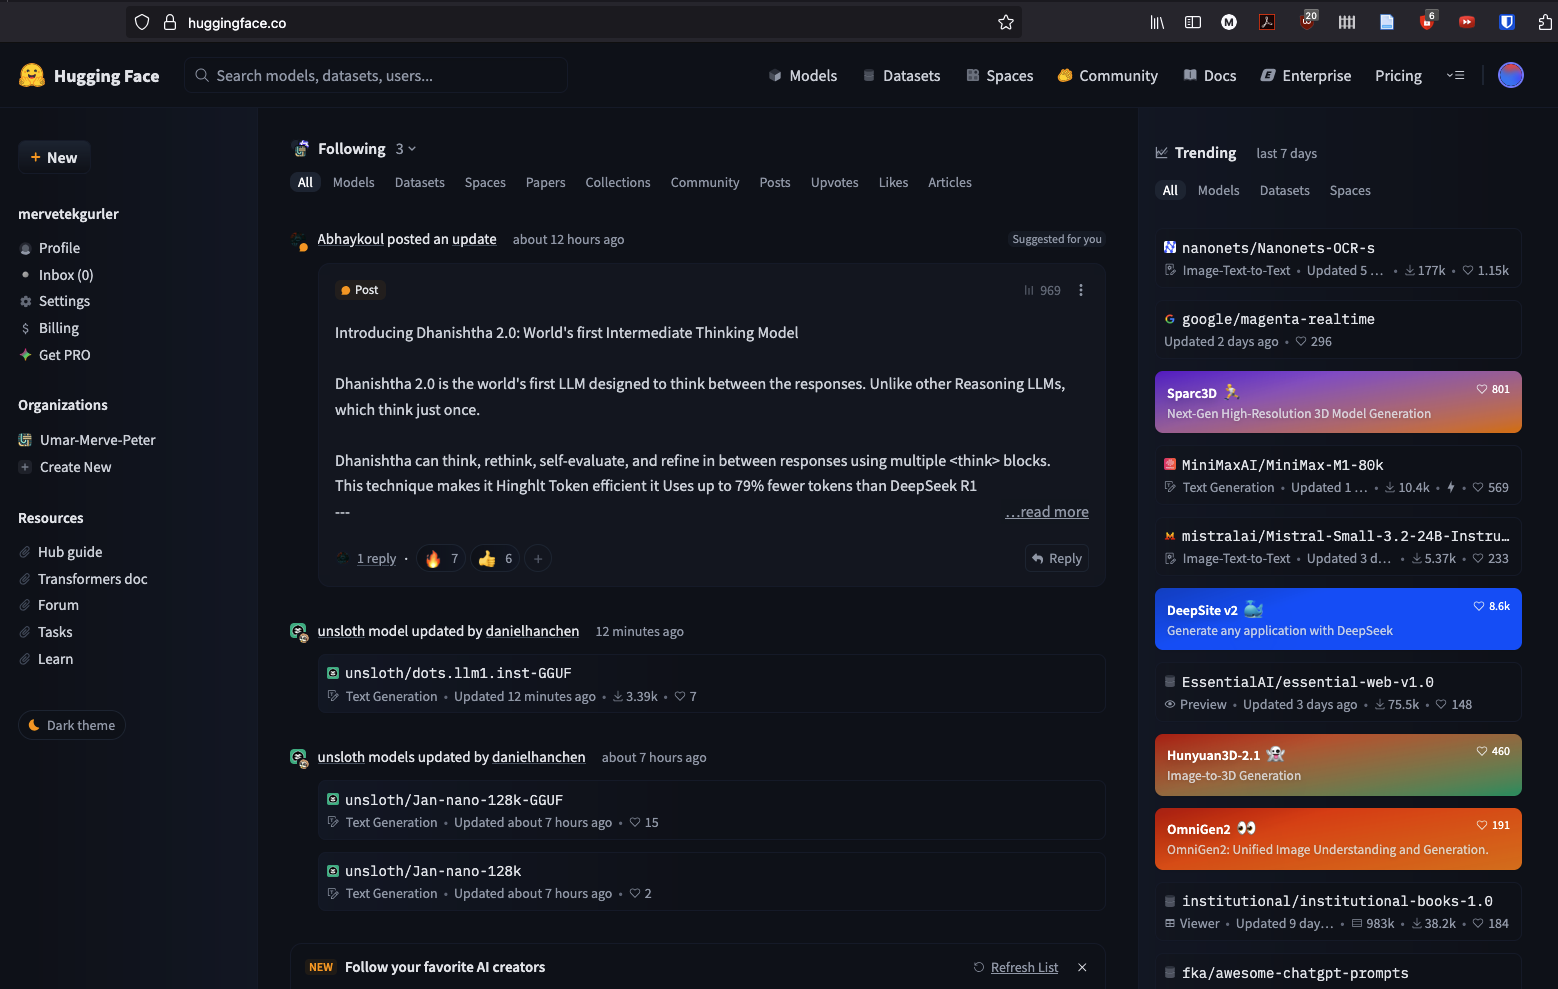


[Hugging Face](https://huggingface.co/) is a company and open-source community known for developing tools and libraries for natural language processing (NLP) and machine learning. They maintain the [Transformers library](https://huggingface.co/docs/transformers/en/index), which provides easy access to pre-trained models. Users can also post their own models on Hugging Face model hub and share datasets as well. Hugging Face [Datasets library](https://huggingface.co/docs/datasets/en/index) allows for easy access to many datasets and offers tools for loading and working with them.



### Model Page Example

[DeepSeek R1 model](https://huggingface.co/deepseek-ai/DeepSeek-R1-0528) is hosted on HuggingFace. There is an inference space where you can interact with the model. You can also download its weights and run it on a/several GPU/s.

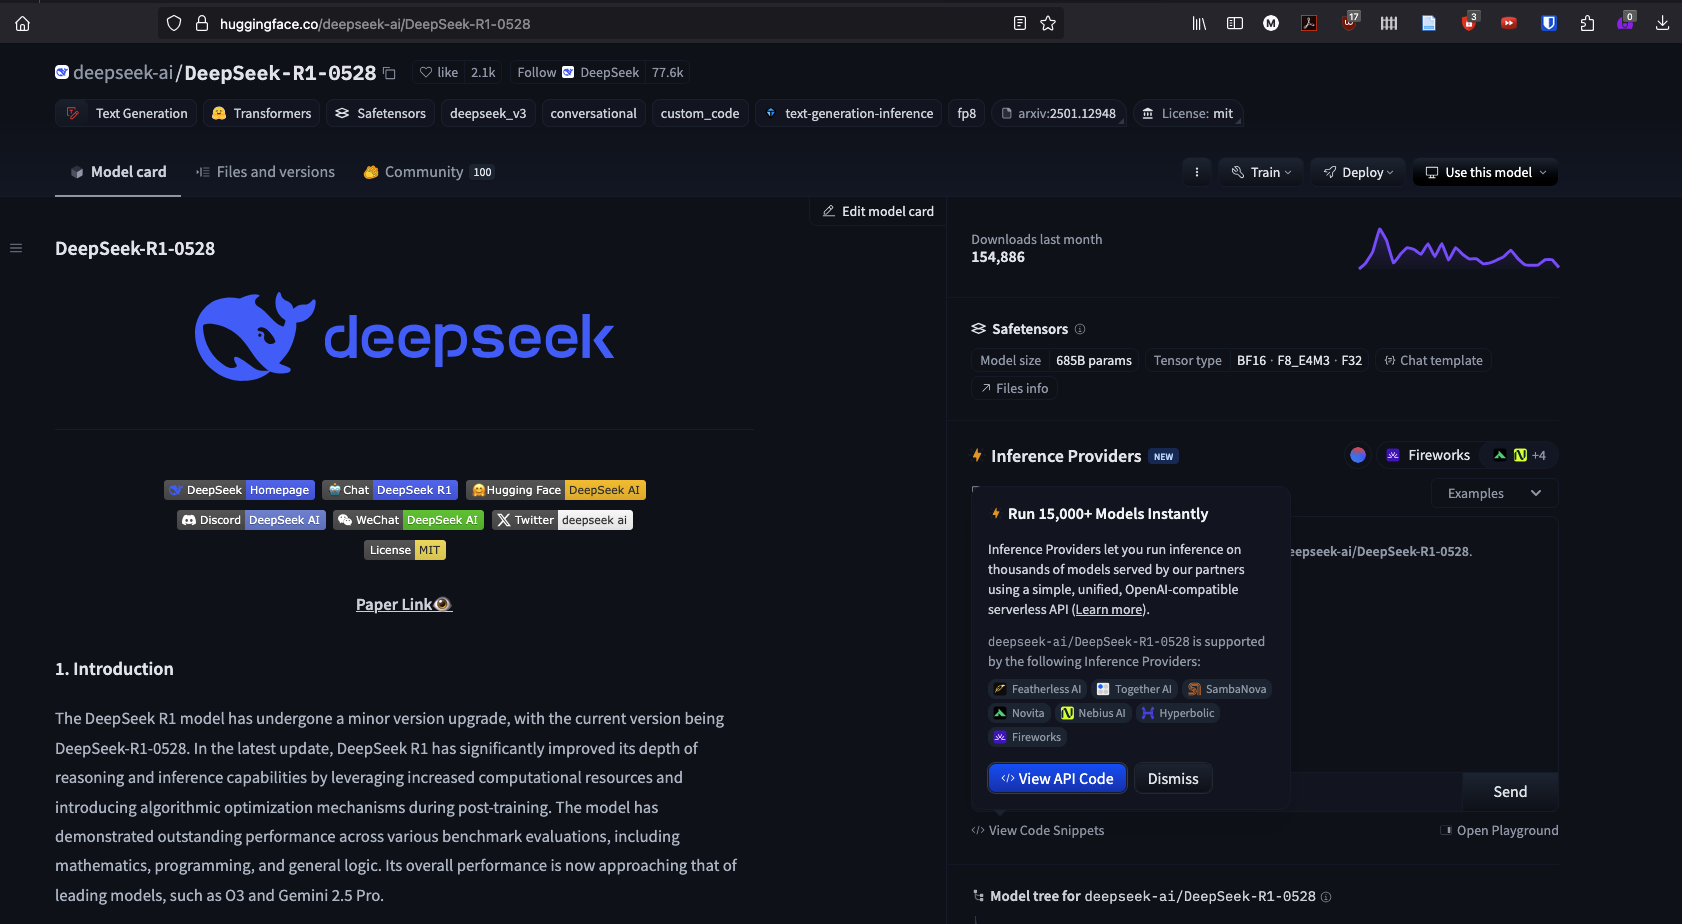

### Datasets

[Muharaf](https://huggingface.co/datasets/aamijar/muharaf-public) dataset is an Arabic handwritten text recognition dataset developed by researchers from North Carolina State University. In the last 5 years or so with the increasing size of datasets, researchers have been releasing their code on GitHub and data on HuggingFace.

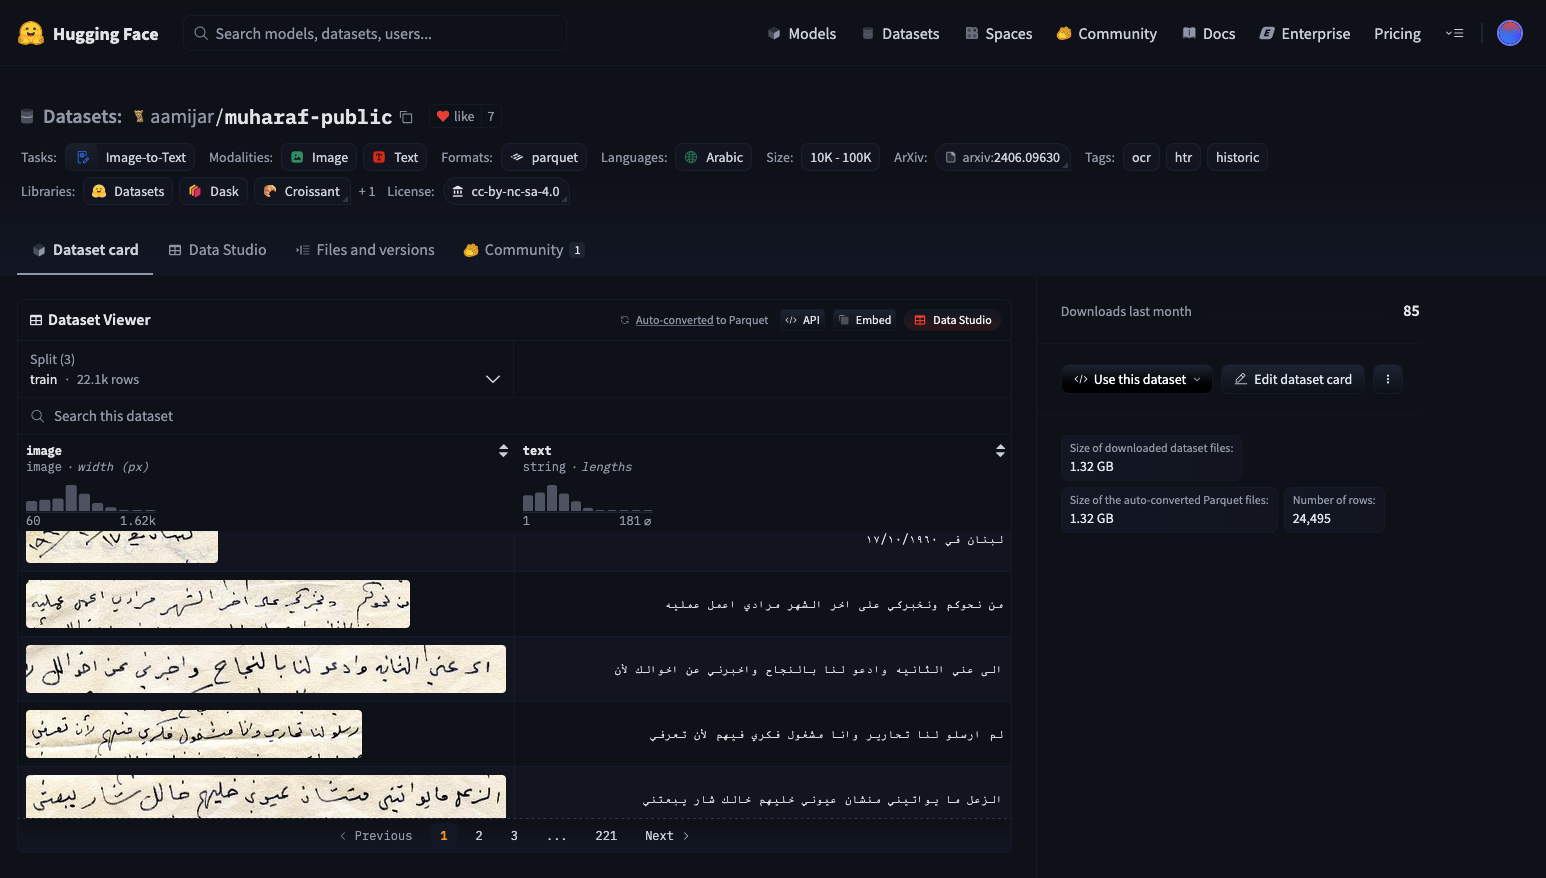

## Why Hugging Face?

As you have seen in your own group project development phase, it is crucial to have an easy access to datasets and example code. Computational research builds upon the work of others in the field. Reproducing their work, understanding and critically studying their approaches, and reusing their data of course with citations, is an essential part of this domain. Hugging Face allows researchers to freely access data and models, creating an open-source community that benefits all its members.



---



## Sentiment Analysis

The code in this notebook comes from this [blog post on HF](https://huggingface.co/blog/sentiment-analysis-python).

Sentiment analysis is a natural language processing (NLP) technique used to determine the *emotional tone or attitude* expressed in a piece of text. While, there are many approaches to sentiment analysis, the most common one classifies text as **positive, negative, or neutral**, and is used to analyze opinions in reviews, social media posts, and customer feedback.

For example, let's take a look at these tweets mentioning @VerizonSupport:

    "dear @verizonsupport your service is straight 💩 in dallas.. been with y’all over a decade and this is all time low for y’all. i’m talking no internet at all." → Would be tagged as "Negative".

    "@verizonsupport ive sent you a dm" → would be tagged as "Neutral".

    "thanks to michelle et al at @verizonsupport who helped push my no-show-phone problem along. order canceled successfully and ordered this for pickup today at the apple store in the mall." → would be tagged as "Positive".

Other examples of sentiment analysis include **more fine-grained distinctions**. Think of Google or Yelp reviews for restaurants, where you are asked to rate a place from 1 to 5 stars. These reviews could also be turned into a 5-category sentiment classifier.

Moreover, **emotion lexicons** are also a part of sentiment analysis in a broader sense. Traditionally in the domain of social psychology, emotion lexicons provide the vocabulary needed to detect and interpret emotions within text. They allow for a more detailed understanding by mapping words to specific emotions like happiness, anger, or sadness. By using emotion lexicons in sentiment analysis, researchers can gain deeper insights into the emotional nuances of a text, going beyond simple polarity.

We will focus on positive-negative sentiment analysis today, but some of your classmates will be presenting about emotion lexicons next week.


In [6]:
# Install required libraries
!pip install datasets transformers huggingface_hub
!apt-get install git-lfs
!pip install -U datasets huggingface_hub fsspec

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.4/515.4 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 13.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.33.0
    Uninstalling huggingface-hub-0.33.0:
      Successfully uninstalled huggingface-hub-0.33.0
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency

In [7]:
# Log in to your Hugging Face account
# Get your API token here https://huggingface.co/settings/token
from huggingface_hub import notebook_login

notebook_login()

### Datasets

We will be working with the IMDB reviews datasets

In [45]:
# Load data
from datasets import load_dataset

imdb = load_dataset("imdb")

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [46]:
# This dataset is really big. You can see it in more detail here
# https://huggingface.co/datasets/ajaykarthick/imdb-movie-reviews

test_dataset = imdb["test"].shuffle(seed=42).select([i for i in list(range(300))])

In [47]:
test_dataset[0]

{'text': "<br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was in it, so what could go wrong?<br /><br />Very quickly, however, I realized that this story was about A Thousand Other Things besides just Acres. I started crying and couldn't stop until long after the movie ended. Thank you Jane, Laura and Jocelyn, for bringing us such a wonderfully subtle and compassionate movie! Thank you cast, for being involved and portraying the characters with such depth and gentleness!<br /><br />I recognized the Angry sister; the Runaway sister and the sister in Denial. I recognized the Abusive Husband and why he was there and then the Father, oh oh the Father... all superbly played. I also recognized myself and this movie was an eye-opener, a relief, a chance to face my OWN truth and finally doing something about it. I truly hope A Thousand Acres has had the same effect on some others out there.<br /><b

In [48]:
len(test_dataset["text"])

300

In [49]:
test_dataset["text"][1]

"This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer to James Bond). The series was launched in the early 1950's, and spawned at least eight films (none of which was ever released in the U.S.). 'O.S.S.117:Cairo,Nest Of Spies' is a breezy little comedy that should not...repeat NOT, be taken too seriously. Our protagonist finds himself in the middle of a spy chase in Egypt (with Morroco doing stand in for Egypt) to find out about a long lost friend. What follows is the standard James Bond/Inspector Cloussou kind of antics. Although our man is something of an overt xenophobe,sexist,homophobe, it's treated as pure farce (as I said, don't take it too seriously). Although there is a bit of rough language & cartoon violence, it's basically okay for older kids (ages 12 & up). As previously stated in the subject line, just sit back,pass the popcorn & just enjoy."

The example code for this actually trains a model on this dataset. We will skip this part and just run inference.

In [50]:
from transformers import pipeline

sentiment_model = pipeline(model="federicopascual/finetuning-sentiment-model-3000-samples")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [51]:
sentiment_model(["I love this move", "This movie sucks!"])

[{'label': 'LABEL_1', 'score': 0.9558863043785095},
 {'label': 'LABEL_0', 'score': 0.9413503408432007}]

In [52]:
sentiment_model("this movie is disgustingly good")

[{'label': 'LABEL_0', 'score': 0.9582885503768921}]

In [53]:
sentiment_model("I have never seen a movie like that")

[{'label': 'LABEL_0', 'score': 0.6323760151863098}]

In [54]:
sentiment_model("A masterpiece in the art of unintentional comedy")

[{'label': 'LABEL_1', 'score': 0.9550999999046326}]

In [55]:
sentiment_model("this movie is sick!")

[{'label': 'LABEL_0', 'score': 0.9595780372619629}]

In [56]:
sentiment_model("This movie was straight-up hot garbage—but like, the kind you weirdly can’t stop watching")

[{'label': 'LABEL_0', 'score': 0.9517907500267029}]

In [57]:
# What happens when we run this on the whole test dataset?
# Can we just use it on any text?

sentiment_model(test_dataset["text"][14])

Token indices sequence length is longer than the specified maximum sequence length for this model (632 > 512). Running this sequence through the model will result in indexing errors


RuntimeError: The size of tensor a (632) must match the size of tensor b (512) at non-singleton dimension 1

When you see this error, it means the input text is too long for the model. Most transformer models like DistilBERT have a maximum input length (usually 512 tokens). If you try to process a text that exceeds this limit, the model cannot handle it and raises an error.

In this case, the text at index 14 is 632 tokens long, but DistilBERT only supports up to 512 tokens. To avoid this error, you need to truncate or shorten long texts before passing them to the model. This ensures the input fits within the model’s allowed size and can be processed correctly.

In [58]:
# Set DistilBERT tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [27]:
# Let's run this on our test set

import pandas as pd

# Get texts and true labels
texts = test_dataset["text"]
true_labels = test_dataset["label"]

# Truncate each text to 512 tokens using the tokenizer
max_length = 512
truncated_texts = []
for t in texts:
    # Tokenize and truncate
    tokens = tokenizer.encode(t, truncation=True, max_length=max_length)
    # Decode back to text for the pipeline
    truncated = tokenizer.decode(tokens, skip_special_tokens=True)
    truncated_texts.append(truncated)

# Run inference
results = sentiment_model(truncated_texts, batch_size=32)

# Extract predictions and scores
predictions = [r['label'] for r in results]
scores = [r['score'] for r in results]

# Create DataFrame
df = pd.DataFrame({
    "text": texts,
    "true_label": true_labels,
    "prediction": predictions,
    "score": scores
})

df.to_csv("sentiment_predictions.csv", index=False)
df.head()

,text,true_label,prediction,score
0,<br /><br />When I unsuspectedly rented A Thou...,1,LABEL_1,0.984232
1,This is the latest entry in the long series of...,1,LABEL_1,0.943269
2,This movie was so frustrating. Everything seem...,0,LABEL_0,0.983311
3,"I was truly and wonderfully surprised at ""O' B...",1,LABEL_1,0.972430
4,This movie spends most of its time preaching t...,0,LABEL_0,0.976243


In [28]:
# Let's evaluate how the model did!

from sklearn.metrics import accuracy_score, f1_score

# Map predictions to integers
# predictions are "LABEL_0"/"LABEL_1", so we convert them to 0/1
pred_map = {"LABEL_0": 0, "LABEL_1": 1}
y_true = df["true_label"]
y_pred = df["prediction"].map(pred_map)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")


Accuracy: 0.867
F1 Score: 0.873


### Accuracy

Accuracy measures the proportion of correct predictions out of all predictions made.

$$
 \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$

Our model predicts the correct label with 87% accuracy

### Precision

Precision measures how many of the items predicted as positive are actually positive.

Or: Of all the items the model predicted as positive, how many were actually positive?

$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
$$

## Recall

Recall measures how many of the actual positive items were correctly predicted.

Or: Of all the actual positive items, how many did the model correctly identify?

$$
\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
$$

## F1 Score

The F1 score is the harmonic mean of precision and recall. It balances the two, especially when classes are imbalanced.

$$
\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In our case, our F1 score is 0.873. F1 score and accuracy are similar, which means that our model is performing well on both positive and negative classes.



---



## Topic Modeling

Topic modeling is an unsupervised machine learning technique used to computationally discover the main themes or topics present in a large collection of texts. Instead of labeling texts as positive or negative (like in sentiment analysis), topic modeling groups texts by the subjects they discuss, helping us understand what people are talking about in a dataset.

"Topic models represent a family of computer programs that extract topics from texts. **A topic to the computer is a list of words that occur in statistically meaningful ways**. A text can be an email, a blog post, a book chapter, a journal article, a diary entry – that is, any kind of unstructured text. By unstructured we mean that there are no computer-readable annotations that tell the computer the semantic meaning of the words in the text.

Topic modeling programs do not know anything about the meaning of the words in a text. Instead, they assume that any piece of text is composed (by an author) by selecting words from possible baskets of words where each basket corresponds to a topic. If that is true, then it becomes possible to mathematically decompose a text into the probable baskets from whence the words first came. The tool goes through this process over and over again until it settles on the most likely distribution of words into baskets, which we call topics."

Topic modeling has been around for a while, especially for digital humanists and computational social scientists. There are many approaches to topic modeling. Most common ones are MALLET and Gensim. You can read about MALLET [here](https://programminghistorian.org/en/lessons/topic-modeling-and-mallet) and Gensim [here](https://radimrehurek.com/gensim/).

### BERTopic

BERTopic is a topic modeling tool that uses transformer-based language models (like BERT) to create high-quality topic representations. BERTopic leverages sentence embeddings, which means it understands words in context and can find more meaningful and coherent topics.

It also allows us to experiment with topic modeling using generative AI models.

We will reproduce the code from this [notebook](https://colab.research.google.com/drive/1BoQ_vakEVtojsd2x_U6-_x52OOuqruj2?usp=sharing)



In [2]:
%%capture
# The %%capture magic command in a Jupyter notebook (or Colab) suppresses the output of the cell.
!pip install bertopic
!pip install datasets
!pip install -U datasets
!pip install openai

# Data
For this example, we will use a dataset containing abstracts and metadata from [ArXiv articles](https://huggingface.co/datasets/arxiv_dataset).

In [1]:
from datasets import load_dataset

dataset = load_dataset("CShorten/ML-ArXiv-Papers")["train"]

# Extract abstracts to train on and corresponding titles
abstracts = dataset["abstract"]
titles = dataset["title"]

README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117592 [00:00<?, ? examples/s]

In [59]:
abstracts[0]

'  The problem of statistical learning is to construct a predictor of a random\nvariable $Y$ as a function of a related random variable $X$ on the basis of an\ni.i.d. training sample from the joint distribution of $(X,Y)$. Allowable\npredictors are drawn from some specified class, and the goal is to approach\nasymptotically the performance (expected loss) of the best predictor in the\nclass. We consider the setting in which one has perfect observation of the\n$X$-part of the sample, while the $Y$-part has to be communicated at some\nfinite bit rate. The encoding of the $Y$-values is allowed to depend on the\n$X$-values. Under suitable regularity conditions on the admissible predictors,\nthe underlying family of probability distributions and the loss function, we\ngive an information-theoretic characterization of achievable predictor\nperformance in terms of conditional distortion-rate functions. The ideas are\nillustrated on the example of nonparametric regression in Gaussian noise.\n'

In [60]:
len(abstracts)

117592

Whenever you have large documents, you typically want to split them up into either paragraphs or sentences. This is important because many natural language processing models, including those used for embeddings or topic modeling, have a maximum input length and work best with shorter, more focused pieces of text. Splitting large documents into smaller chunks—like sentences—makes it easier to analyze, compare, and visualize the content.

You can use NLTK for this!

```python
from nltk.tokenize import sent_tokenize, word_tokenize
sentences = [sent_tokenize(abstract) for abstract in abstracts]
sentences = [sentence for doc in sentences for sentence in doc]
```

### What is BERTopic?

BERTopic can be viewed as a sequence of steps to create its topic representations. There are five steps to this process:

![https://maartengr.github.io/BERTopic/algorithm/default.svg](https://maartengr.github.io/BERTopic/algorithm/default.svg)


The pipeline above implies significant modularity of BERTopic. Each step in this process was carefully selected such that they are all somewhat independent from one another.

As a result, we can adopt the pipeline to the current state-of-the-art with respect to each individual step:

 ![https://maartengr.github.io/BERTopic/algorithm/modularity.svg](https://maartengr.github.io/BERTopic/algorithm/modularity.svg)

### **Pre-calculate Embeddings**
After having created our data, namely `abstracts`, we can dive into the very first best practice, **pre-calculating embeddings**.

BERTopic works by converting documents into numerical values, called embeddings. This process can be very costly, especially if we want to iterate over parameters. Instead, we can calculate those embeddings once and feed them to BERTopic to skip calculating embeddings each time.

In [11]:
from sentence_transformers import SentenceTransformer

# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3675 [00:00<?, ?it/s]

In [12]:
# it took us a while even with a GPU runtime to create these embeddings
# let's make sure to save them

import numpy as np

np.save("embeddings.npy", embeddings)

In [ ]:
# We can load embeddings like this

# embeddings = np.load("embeddings.npy")

If this notebook is not mounted to Drive, you will end up saving it in a temporary disk. If that is the case, download your embeddings from Files (folder icon on the left navigation bar)

### **Preventing Stochastic Behavior**
In BERTopic, we generally use a dimensionality reduction algorithm to reduce the size of the embeddings. This is done to prevent the [curse of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality) to a certain degree.

As a default, this is done with [UMAP](https://github.com/lmcinnes/umap) which is an incredible algorithm for reducing dimensional space. However, by default, it shows stochastic behavior which creates different results each time you run it. To prevent that, we will need to set a `random_state` of the model before passing it to BERTopic.

As a result, we can now fully reproduce the results each time we run the model.

In [13]:
from umap import UMAP

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

### **Controlling Number of Topics**
There is a parameter to control the number of topics, namely `nr_topics`. This parameter, however, merges topics **after** they have been created. It is a parameter that supports creating a fixed number of topics.

However, it is advised to control the number of topics through the cluster model which is by default HDBSCAN. HDBSCAN has a parameter, namely `min_cluster_size` that indirectly controls the number of topics that will be created.

A higher `min_cluster_size` will generate fewer topics and a lower `min_cluster_size` will generate more topics.

Here, we will go with `min_cluster_size=150` to prevent too many micro-clusters from being created

In [14]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(min_cluster_size=150, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

### **Improving Default Representation**
The default representation of topics is calculated through [c-TF-IDF](https://maartengr.github.io/BERTopic/algorithm/algorithm.html#5-topic-representation). However, c-TF-IDF is powered by the [CountVectorizer](https://maartengr.github.io/BERTopic/getting_started/vectorizers/vectorizers.html) which converts text into tokens. Using the CountVectorizer, we can do a number of things:

* Remove stopwords
* Ignore infrequent words
* Increase the n-gram range

In other words, we can preprocess the topic representations **after** documents are assigned to topics. This will not influence the clustering process in any way.

Here, we will ignore English stopwords and infrequent words. Moreover, by increasing the n-gram range we will consider topic representations that are made up of one or two words.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))

### **Additional Representations**
Previously, we have tuned the default representation but there are quite a number of [other topic representations](https://maartengr.github.io/BERTopic/getting_started/representation/representation.html) in BERTopic that we can choose from. From [KeyBERTInspired](https://maartengr.github.io/BERTopic/getting_started/representation/representation.html#keybertinspired) and [PartOfSpeech](https://maartengr.github.io/BERTopic/getting_started/representation/representation.html#partofspeech), to [OpenAI's ChatGPT](https://maartengr.github.io/BERTopic/getting_started/representation/llm.html#chatgpt) and [open-source](https://maartengr.github.io/BERTopic/getting_started/representation/llm.html#langchain) alternatives, many representations are possible.

In BERTopic, you can model many different topic representations simultanously to test them out and get different perspectives of topic descriptions. This is called [multi-aspect](https://maartengr.github.io/BERTopic/getting_started/multiaspect/multiaspect.html) topic modeling.

Here, we will demonstrate a number of interesting and useful representations in BERTopic:

* KeyBERTInspired
  * A method that derives inspiration from how KeyBERT works
* PartOfSpeech
  * Using SpaCy's POS tagging to extract words
* MaximalMarginalRelevance
  * Diversify the topic words
* OpenAI
  * Use ChatGPT to label our topics

In [28]:
import openai
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech

# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm")

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model
}

We are skipping OpenAI here but we will circle back to it later

### **Training**
Now that we have a set of best practices, we can use them in our training loop. Here, several different representations, keywords and labels for our topics will be created. If you want to iterate over the topic model it is advised to use the pre-calculated embeddings as that significantly speeds up training.

In [29]:
from bertopic import BERTopic

topic_model = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=hdbscan_model,
  vectorizer_model=vectorizer_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

topics, probs = topic_model.fit_transform(abstracts, embeddings)

2025-06-25 19:36:15,388 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-25 19:39:24,231 - BERTopic - Dimensionality - Completed ✓
2025-06-25 19:39:24,237 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-25 19:39:44,320 - BERTopic - Cluster - Completed ✓
2025-06-25 19:39:44,353 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-25 19:41:54,932 - BERTopic - Representation - Completed ✓


### Save/Load BERTopic model



There are three methods for saving BERTopic:

    A light model with .safetensors and config files
    A light model with pytorch .bin and config files
    A full model with .pickle

Method 3 allows for saving the entire topic model but has several drawbacks:

    Arbitrary code can be run from .pickle files
    The resulting model is rather large (often > 500MB) since all sub-models need to be saved
    Explicit and specific version control is needed as they typically only run if the environment is exactly the same

    It is advised to use methods 1 or 2 for saving.

These methods have a number of advantages:

    .safetensors is a relatively safe format
    The resulting model can be very small (often < 20MB) since no sub-models need to be saved
    Although version control is important, there is a bit more flexibility with respect to specific versions of packages
    More easily used in production
    Share models with the HuggingFace Hub


```python
# Method 1 - safetensors
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
topic_model.save("path/to/my/model_dir", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

# Method 2 - pytorch
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
topic_model.save("path/to/my/model_dir", serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

# Method 3 - pickle
topic_model.save("my_model", serialization="pickle")
```

In [32]:
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
topic_model.save("my_model", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

In [ ]:
# Load from directory
# topic_model = BERTopic.load("path/to/my/model_dir")

# Load from file
# topic_model = BERTopic.load("my_model")


### Topic Models

In this section we will look at the topic models that we created

In [30]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,-1,37811,-1_data_learning_model_models,"[data, learning, model, models, based, trainin...","[deep learning, learning, deep, neural network...","[data, models, training, neural, performance, ...","[data, learning, model, models, training, neur...","[ In this paper, we present a new adaptive fe..."
1,0,5552,0_policy_reinforcement_reinforcement learning_rl,"[policy, reinforcement, reinforcement learning...","[policy gradient, reinforcement learning, imit...","[reinforcement, reinforcement learning, rl, po...","[policy, reinforcement, learning, reward, agen...",[ Reinforcement Learning (RL) based methods h...
2,1,3478,1_speech_audio_speaker_music,"[speech, audio, speaker, music, acoustic, asr,...","[speech enhancement, automatic speech, voice, ...","[audio, speaker, acoustic, asr, speech recogni...","[speech, audio, speaker, music, acoustic, reco...",[ Voice cloning is a highly desired feature f...
3,2,3244,2_3d_object_video_segmentation,"[3d, object, video, segmentation, image, objec...","[3d, semantic segmentation, cnn, object detect...","[3d, segmentation, pose, object detection, vis...","[object, video, segmentation, image, objects, ...",[ Monocular multi-object detection and locali...
4,3,2072,3_graph_node_graphs_gnns,"[graph, node, graphs, gnns, nodes, graph neura...","[graph neural, graph learning, graph classific...","[graphs, nodes, graph neural, networks, node c...","[graph, node, graphs, nodes, networks, embeddi...",[ Graph neural networks (GNNs) have significa...
...,...,...,...,...,...,...,...,...
115,114,163,114_clustering_deep clustering_deep_cluster,"[clustering, deep clustering, deep, cluster, u...","[deep clustering, unsupervised clustering, dee...","[deep clustering, cluster, unsupervised, laten...","[clustering, deep clustering, deep, cluster, u...","[ Recently, deep clustering, which is able to..."
116,115,158,115_crowdsourcing_workers_crowd_labels,"[crowdsourcing, workers, crowd, labels, worker...","[crowdsourcing data, crowdsourcing, crowdsourc...","[crowdsourcing, crowdsourced, annotators, anno...","[crowdsourcing, workers, crowd, labels, worker...",[ We raise and define a new crowdsourcing sce...
117,116,154,116_graph_attack_gnns_attacks,"[graph, attack, gnns, attacks, adversarial, no...","[graph adversarial, adversarial attack, attack...","[gnns, attacks, adversarial, node, adversarial...","[graph, attack, attacks, adversarial, node, ad...",[ Graph Neural Networks (GNNs) are powerful t...
118,117,153,117_view_multi view_views_multi,"[view, multi view, views, multi, clustering, v...","[view clustering, view learning, view classifi...","[multi view, views, clustering, view clusterin...","[view, views, multi, clustering, view clusteri...",[ Multi-view clustering has attracted much at...


To get all representations for a single topic, we simply run the following:

In [61]:
topic_model.get_topic(1, full=True)

{'Main': [('speech', np.float64(0.030756314996118507)),
  ('audio', np.float64(0.01909584510357801)),
  ('speaker', np.float64(0.016532645105091504)),
  ('music', np.float64(0.012338847121346606)),
  ('acoustic', np.float64(0.009783461517698051)),
  ('asr', np.float64(0.009384066750579581)),
  ('recognition', np.float64(0.009171426627119408)),
  ('speech recognition', np.float64(0.008169696131084134)),
  ('voice', np.float64(0.007647607935833313)),
  ('end', np.float64(0.007473489630674636))],
 'KeyBERT': [('speech enhancement', np.float32(0.570972)),
  ('automatic speech', np.float32(0.56179255)),
  ('voice', np.float32(0.5160459)),
  ('speech recognition', np.float32(0.51545525)),
  ('speaker verification', np.float32(0.44872108)),
  ('audio', np.float32(0.4221178)),
  ('encoder', np.float32(0.37219736)),
  ('speaker', np.float32(0.3676309)),
  ('speech', np.float32(0.35503757)),
  ('recognition asr', np.float32(0.3533321))],
 'MMR': [('audio', np.float64(0.01909584510357801)),
  ('s

### **Topic-Document Distribution**
If using `calculate_probabilities=True` is not possible, than you can [approximate the topic-document distributions](https://maartengr.github.io/BERTopic/getting_started/distribution/distribution.html) using `.approximate_distribution`. It is a fast and flexible method for creating different topic-document distributions.

In [33]:
# `topic_distr` contains the distribution of topics in each document
topic_distr, _ = topic_model.approximate_distribution(abstracts, window=8, stride=4)

100%|██████████| 118/118 [02:05<00:00,  1.06s/it]


Next, lets take a look at a specific abstract and see how the topic distribution was extracted:

In [62]:
abstract_id = 10
print(abstracts[abstract_id])

  Speaker identification is a powerful, non-invasive and in-expensive biometric
technique. The recognition accuracy, however, deteriorates when noise levels
affect a specific band of frequency. In this paper, we present a sub-band based
speaker identification that intends to improve the live testing performance.
Each frequency sub-band is processed and classified independently. We also
compare the linear and non-linear merging techniques for the sub-bands
recognizer. Support vector machines and Gaussian Mixture models are the
non-linear merging techniques that are investigated. Results showed that the
sub-band based method used with linear merging techniques enormously improved
the performance of the speaker identification over the performance of wide-band
recognizers when tested live. A live testing improvement of 9.78% was achieved



In [64]:
# Visualize the topic-document distribution for a single document
topic_model.visualize_distribution(topic_distr[abstract_id])

IndexError: index 10 is out of bounds for axis 0 with size 1

It seems to have extracted a number of topics that are relevant and shows the distributions of these topics across the abstract. We can go one step further and visualize them on a token-level:

In [36]:
# Calculate the topic distributions on a token-level
topic_distr, topic_token_distr = topic_model.approximate_distribution(abstracts[abstract_id], calculate_tokens=True)

# Visualize the token-level distributions
df = topic_model.visualize_approximate_distribution(abstracts[abstract_id], topic_token_distr[0])
df

100%|██████████| 1/1 [00:00<00:00,  5.26it/s]


,Speaker,identification,is,powerful,non,invasive,and,in,expensive,biometric,technique,The,recognition,accuracy,however,deteriorates,when,noise,levels,affect,specific,band,of,frequency,In,this,paper,we,present,sub,band,based,speaker,identification,that,intends,to,improve,the,live,testing,performance,Each,frequency,sub,band,is,processed,and,classified,independently,We,also,compare,the,linear,and,non,linear,merging,techniques,for,the,sub,bands,recognizer,Support,vector,machines,and,Gaussian,Mixture,models,are,the,non,linear,merging,techniques,that,are,investigated,Results,showed,that,the,sub,band,based,method,used,with,linear,merging,techniques,enormously,improved,the,performance,of,the,speaker,identification,over,the,performance,of,wide,band,recognizers,when,tested,live,live,testing,improvement,of,78,was,achieved
1_speech_audio_speaker_music,0.113,0.113,0.113,0.113,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.101,0.101,0.101,0.101,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.110,0.229,0.348,0.467,0.357,0.238,0.119,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
13_gaussian_variational_inference_gp,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.112,0.225,0.225,0.225,0.112,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
67_emotion_emotion recognition_recognition_emotions,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.113,0.113,0.113,0.113,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
93_handwritten_text_character_recognition,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.115,0.115,0.115,0.115,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
95_svm_support vector_support_vector,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00

### **Outlier Reduction**
By default, HDBSCAN generates outliers which is a helpful mechanic in creating accurate topic representations. However, you might want to assign every single document to a topic. We can use `.reduce_outliers` to map some or all outliers to a topic:

In [37]:
# Reduce outliers
new_topics = topic_model.reduce_outliers(abstracts, topics)

# Reduce outliers with pre-calculate embeddings instead
new_topics = topic_model.reduce_outliers(abstracts, topics, strategy="embeddings", embeddings=embeddings)

100%|██████████| 38/38 [01:27<00:00,  2.30s/it]


**💡  NOTE - Update Topics with Outlier Reduction 💡**
***
After having generated updated topic assignments, we can pass them to BERTopic in order to update the topic representations:

```python
topic_model.update_topics(docs, topics=new_topics)
```

It is important to realize that updating the topics this way may lead to errors if topic reduction or topic merging techniques are used afterwards. The reason for this is that when you assign a -1 document to topic 1 and another -1 document to topic 2, it is unclear how you map the -1 documents. Is it matched to topic 1 or 2.
***

## **Visualize Topics**

With visualizations, we are closing into the realm of subjective "best practices". These are things that I generally do because I like the representations but your experience might differ.

Having said that, there are two visualizations that are my go-to when visualizing the topics themselves:

* `topic_model.visualize_topics()`
* `topic_model.visualize_hierarchy()`

In [38]:
topic_model.visualize_topics()

In [39]:
topic_model.visualize_hierarchy()

## **Visualize Documents**

When visualizing documents, it helps to have embedded the documents beforehand to speed up computation. Fortunately, we have already done that as a "best practice".

Visualizing documents in 2-dimensional space helps in understanding the underlying structure of the documents and topics.

In [40]:
# Reduce dimensionality of embeddings, this step is optional but much faster to perform iteratively:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

The following plot is **interactive** which means that you can zoom in, double click on a label to only see that one and generally interact with the plot:

In [41]:
# Visualize the documents in 2-dimensional space and show the titles on hover instead of the abstracts
# NOTE: You can hide the hover with `hide_document_hover=True` which is especially helpful if you have a large dataset
topic_model.visualize_documents(titles, reduced_embeddings=reduced_embeddings)

Output hidden; open in https://colab.research.google.com to view.

In [42]:
# We can also hide the annotation to have a more clear overview of the topics
topic_model.visualize_documents(titles, reduced_embeddings=reduced_embeddings, hide_annotations=True)

Output hidden; open in https://colab.research.google.com to view.